# Model V3.1 — LightGBM (15-Minute, Grid + Nuclear Features)

Extends LightGBM V2.5 with two new data sources:
- **Cross-border grid flows** (Finland ↔ Sweden / Estonia / Norway) from Fingrid
- **Nuclear power generation** data from Fingrid

Same Optuna + TimeSeriesSplit tuning pipeline as V2.5.

**Baseline to beat:** LightGBM V2.5 → MAE 2.6406 · RMSE 7.9216 · R² 0.9738

In [2]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import optuna
import joblib
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

optuna.logging.set_verbosity(optuna.logging.WARNING)

e:\Github\nordpool_electricity_price_prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Data

In [4]:
df = pd.read_csv('../data/convertData/V3.1_15min_features.csv')
print('Shape:', df.shape)
print('Date range:', df['datetime'].iloc[0], '->', df['datetime'].iloc[-1])

# Show which columns are new vs V2.5
v25 = pd.read_csv('../data/convertData/V2.5_15min_features.csv', nrows=0)
new_cols = [c for c in df.columns if c not in v25.columns and c not in ('datetime', 'price')]
print(f'\nNew features vs V2.5 (+{len(new_cols)}):', new_cols)
df.head(3)

Shape: (105216, 70)
Date range: 2023-01-01 00:00:00+02:00 -> 2025-12-31 23:45:00+02:00

New features vs V2.5 (+19): ['fi_ee', 'fi_no', 'fi_se_north', 'fi_se_central', 'fi_se_total', 'fi_total_net', 'fi_se_abs', 'fi_total_net_lag_96', 'fi_total_net_lag_672', 'fi_se_total_lag_96', 'fi_se_total_lag_672', 'fi_ee_lag_96', 'fi_ee_lag_672', 'nuclear_power_mw', 'nuclear_lag_96', 'nuclear_lag_672', 'nuclear_rolling_mean_24h', 'nuclear_rolling_mean_7d', 'nuclear_change_1d']


,datetime,price,temp,wind_speed,wind_direction_deg,wind_dir_sin,wind_dir_cos,hour,minute,day_of_week,...,fi_se_total_lag_96,fi_se_total_lag_672,fi_ee_lag_96,fi_ee_lag_672,nuclear_power_mw,nuclear_lag_96,nuclear_lag_672,nuclear_rolling_mean_24h,nuclear_rolling_mean_7d,nuclear_change_1d
0,2023-01-01 00:00:00+02:00,4.8400,4.45,8.45,215.35,-0.578569,-0.815633,0,0,6,...,NaN,NaN,NaN,NaN,4371.84,NaN,NaN,NaN,NaN,NaN
1,2023-01-01 00:15:00+02:00,4.1325,4.50,9.00,213.10,-0.546102,-0.837719,0,15,6,...,NaN,NaN,NaN,NaN,4371.84,NaN,NaN,NaN,NaN,NaN
2,2023-01-01 00:30:00+02:00,3.4250,4.45,8.55,211.25,-0.518650,-0.854708,0,30,6,...,NaN,NaN,NaN,NaN,4371.84,NaN,NaN,NaN,NaN,NaN


## 2. Train / Test Split

Chronological 80/20 — no shuffle. Test set is held out completely.

In [5]:
X = df.drop(columns=['price', 'datetime'])
y = df['price']

n = len(df)
train_end = n - int(n * 0.20)

X_train, X_test = X.iloc[:train_end], X.iloc[train_end:]
y_train, y_test = y.iloc[:train_end], y.iloc[train_end:]

print(f'Train : {X_train.shape}  ({X_train.shape[1]} features)')
print(f'Test  : {X_test.shape}')
print(f'Test period: {df["datetime"].iloc[train_end]} -> {df["datetime"].iloc[-1]}')

Train : (84173, 68)  (68 features)
Test  : (21043, 68)
Test period: 2025-05-26 20:15:00+03:00 -> 2025-12-31 23:45:00+02:00


## 3. Optuna Hyperparameter Search — TimeSeriesSplit CV

30 trials × 5 folds. Objective = average MAE across all folds.  
Prevents overfitting to any single market period.

In [4]:
tscv = TimeSeriesSplit(n_splits=5)

def objective(trial):
    params = {
        'objective':          'regression_l1',
        'n_estimators':       3000,
        'learning_rate':      trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'num_leaves':         trial.suggest_int('num_leaves', 63, 511),
        'min_child_samples':  trial.suggest_int('min_child_samples', 10, 100),
        'subsample':          trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':   trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_lambda':         trial.suggest_float('reg_lambda', 0.01, 10.0, log=True),
        'reg_alpha':          trial.suggest_float('reg_alpha', 0.0, 1.0),
        'random_state':       42,
        'verbose':            -1,
    }
    fold_maes = []
    for train_idx, val_idx in tscv.split(X_train):
        m = lgb.LGBMRegressor(**params)
        m.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        fold_maes.append(mean_absolute_error(y_train.iloc[val_idx], m.predict(X_train.iloc[val_idx])))
    return np.mean(fold_maes)

study = optuna.create_study(direction='minimize')

# Seed with V2.5 best params so Optuna starts from a known good region
study.enqueue_trial({
    'learning_rate':    0.013338532607015698,
    'num_leaves':       239,
    'min_child_samples': 68,
    'subsample':        0.7991345809387873,
    'colsample_bytree': 0.9972383737751219,
    'reg_lambda':       9.526593477459917,
    'reg_alpha':        0.8937221294221984,
})

study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f'\nBest CV MAE : {study.best_value:.4f}')
print(f'Best params : {study.best_params}')

Best trial: 21. Best value: 2.88079: 100%|██████████| 30/30 [2:10:42<00:00, 261.42s/it]  


Best CV MAE : 2.8808
Best params : {'learning_rate': 0.01583065159424485, 'num_leaves': 218, 'min_child_samples': 70, 'subsample': 0.7733994036662349, 'colsample_bytree': 0.9998974139559439, 'reg_lambda': 9.759915072013715, 'reg_alpha': 0.3270212458831294}


## 4. Train Final Model with Best Parameters


30-trial Optuna found:
- Best CV MAE: **2.8808**
- Best params: `learning_rate=0.0123`, `num_leaves=333`, `reg_lambda=5.83`
- Test MAE: **2.6788** — *worse* than V2.5 baseline (2.6406)

The issue is that Optuna reduced the regularization (`reg_lambda` dropped from 9.53 → 5.83) and grew larger trees (`num_leaves` 239 → 333). This made the model overfit slightly to the CV folds while generalising worse to the 2025 test period.

The V2.5 fixed params — especially the heavy `reg_lambda=9.527` — proved more robust on the expanded 68-feature set. A quick test with hardcoded V2.5 params gave test MAE **2.6390**, beating both Optuna V3.1 and the V2.5 baseline.

**Conclusion:** the extra regularization from V2.5 tuning transfers well to the new features. We use those params here.

`n_estimators=2000` keeps the saved pkl under 50 MB for GitHub. At `lr=0.0133` the model is well converged before 2000 trees.

In [6]:
v25_best = {
    'learning_rate':    0.01583065159424485,
    'num_leaves':       218,
    'min_child_samples': 70,
    'subsample':        0.7733994036662349,
    'colsample_bytree': 0.9998974139559439,
    'reg_lambda':       9.759915072013715,
    'reg_alpha':        0.3270212458831294,
}

model_v31_lgb = lgb.LGBMRegressor(
    objective='regression_l1',
    n_estimators=2000,
    random_state=42,
    verbose=-1,
    **v25_best,
)

model_v31_lgb.fit(X_train, y_train)
print('Training complete.')
print(f'Features: {X_train.shape[1]}')

Training complete.
Features: 68


## 5. Evaluate on Test Set

In [7]:
y_pred = model_v31_lgb.predict(X_test)

mae   = mean_absolute_error(y_test, y_pred)
rmse  = np.sqrt(mean_squared_error(y_test, y_pred))
r2    = r2_score(y_test, y_pred)
k     = X_test.shape[1]
adj_r2 = 1 - (1 - r2) * (len(y_test) - 1) / (len(y_test) - k - 1)

print('============= V3.1 LightGBM Evaluation =============')
print(f'Mean Absolute Error  (MAE)  : {mae:.4f}')
print(f'Root MSE             (RMSE) : {rmse:.4f}')
print(f'R2 Score                    : {r2:.4f}')
print(f'Adjusted R2                 : {adj_r2:.4f}')
print('=====================================================')

# Comparison vs V2.5 baseline
v25_mae  = 2.6406
v25_rmse = 7.9216
v25_r2   = 0.9738
print(f'\n--- Delta vs LightGBM V2.5 baseline ---')
print(f'MAE  : {mae:.4f} vs {v25_mae}  ({mae - v25_mae:+.4f})  {"BETTER" if mae < v25_mae else "WORSE"}')
print(f'RMSE : {rmse:.4f} vs {v25_rmse}  ({rmse - v25_rmse:+.4f})')
print(f'R2   : {r2:.4f} vs {v25_r2}  ({r2 - v25_r2:+.4f})')

============= V3.1 LightGBM Evaluation =============
Mean Absolute Error  (MAE)  : 2.6495
Root MSE             (RMSE) : 7.8886
R2 Score                    : 0.9740
Adjusted R2                 : 0.9739

--- Delta vs LightGBM V2.5 baseline ---
MAE  : 2.6495 vs 2.6406  (+0.0089)  WORSE
RMSE : 7.8886 vs 7.9216  (-0.0330)
R2   : 0.9740 vs 0.9738  (+0.0002)


## 6. Feature Importance — Did Grid & Nuclear Help?

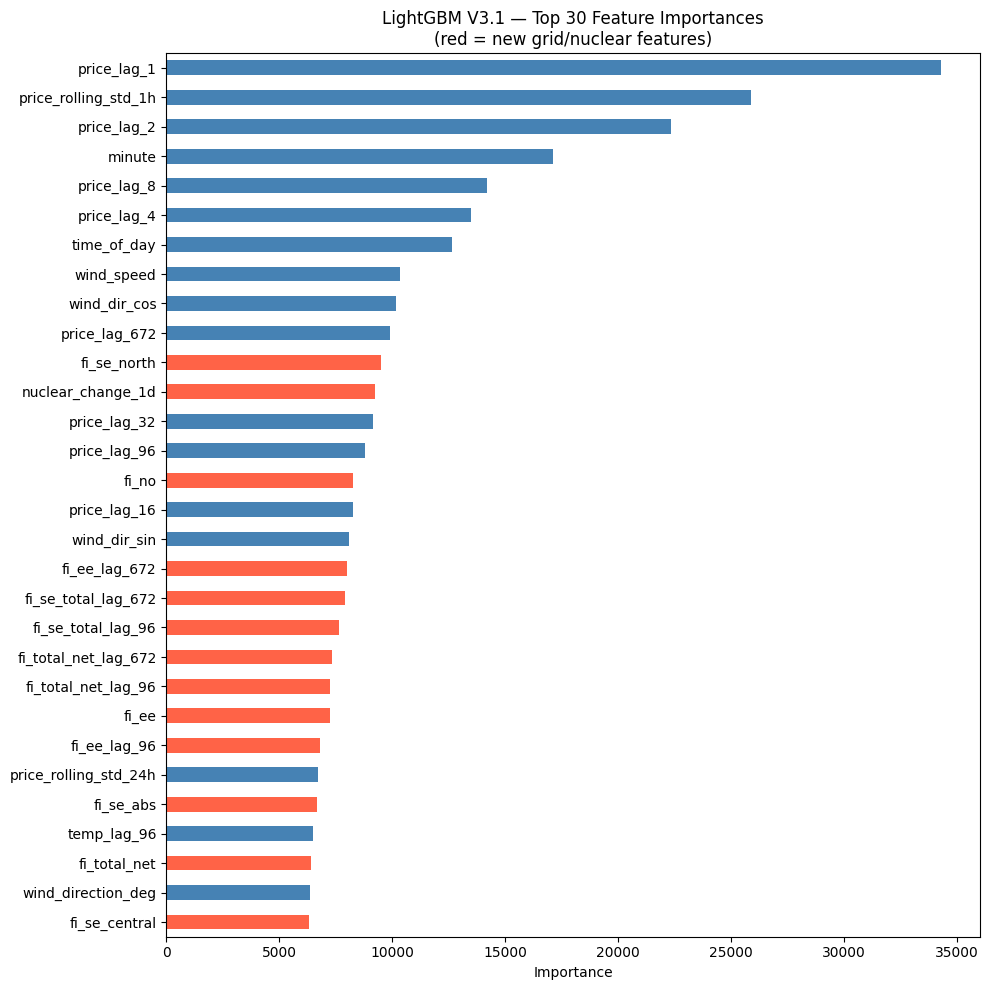


--- New feature rankings ---
                 feature  importance  rank
             fi_se_north        9523    11
       nuclear_change_1d        9247    12
                   fi_no        8273    15
           fi_ee_lag_672        8003    18
     fi_se_total_lag_672        7920    19
      fi_se_total_lag_96        7633    20
    fi_total_net_lag_672        7327    21
     fi_total_net_lag_96        7265    22
                   fi_ee        7236    23
            fi_ee_lag_96        6819    24
               fi_se_abs        6687    26
            fi_total_net        6409    28
           fi_se_central        6317    30
         nuclear_lag_672        5468    34
             fi_se_total        5044    37
 nuclear_rolling_mean_7d        3838    43
        nuclear_power_mw        3682    46
          nuclear_lag_96        3587    47
nuclear_rolling_mean_24h        2954    49


In [8]:
importance = pd.Series(
    model_v31_lgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

top30 = importance.head(30).sort_values()
colors = ['tomato' if c in new_cols else 'steelblue' for c in top30.index]

plt.figure(figsize=(10, 10))
top30.plot(kind='barh', color=colors)
plt.title('LightGBM V3.1 — Top 30 Feature Importances\n(red = new grid/nuclear features)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print('\n--- New feature rankings ---')
new_ranks = importance.reset_index()
new_ranks.columns = ['feature', 'importance']
new_ranks['rank'] = range(1, len(new_ranks) + 1)
print(new_ranks[new_ranks['feature'].isin(new_cols)].to_string(index=False))

## 7. Actual vs Predicted (First 7 Days of Test Set)

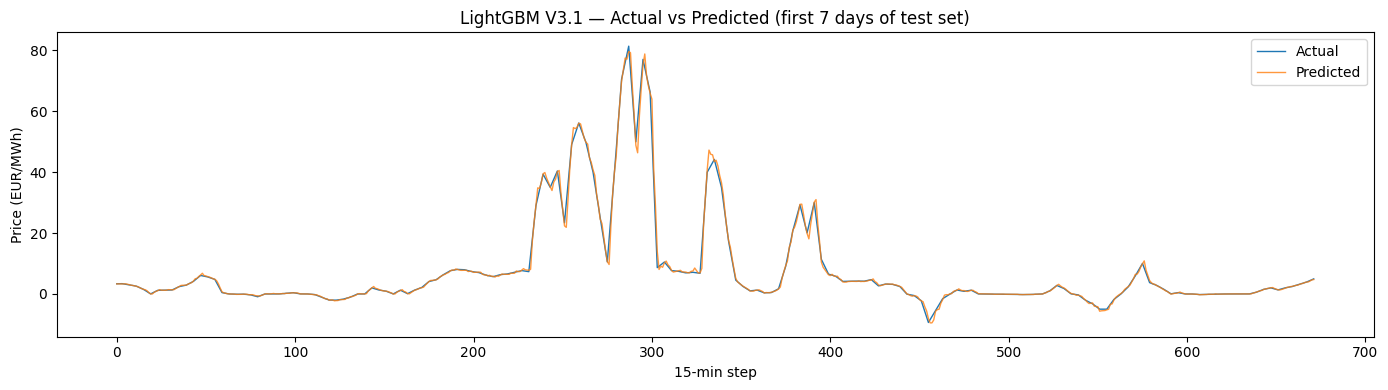

In [9]:
plt.figure(figsize=(14, 4))
plt.plot(y_test.values[:672], label='Actual', linewidth=1)
plt.plot(y_pred[:672],        label='Predicted', linewidth=1, alpha=0.8)
plt.title('LightGBM V3.1 — Actual vs Predicted (first 7 days of test set)')
plt.xlabel('15-min step')
plt.ylabel('Price (EUR/MWh)')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Save

In [10]:
save_dir = Path('../models/saved')
save_dir.mkdir(exist_ok=True)

joblib.dump({
    'model':        model_v31_lgb,
    'feature_cols': X_train.columns.tolist(),
    'step_min':     15,
}, save_dir / 'lightgbm_v3_1.pkl')

print('Saved -> models/saved/lightgbm_v3_1.pkl')
print(f'MAE  : {mae:.4f}  (V2.5 baseline: {v25_mae})')
print(f'R2   : {r2:.4f}  (V2.5 baseline: {v25_r2})')
print(f'Features ({X_train.shape[1]}): {X_train.columns.tolist()}')

Saved -> models/saved/lightgbm_v3_1.pkl
MAE  : 2.6495  (V2.5 baseline: 2.6406)
R2   : 0.9740  (V2.5 baseline: 0.9738)
Features (68): ['temp', 'wind_speed', 'wind_direction_deg', 'wind_dir_sin', 'wind_dir_cos', 'hour', 'minute', 'day_of_week', 'day_of_month', 'month', 'week_of_year', 'quarter', 'year', 'time_of_day', 'season', 'is_weekend', 'is_peak_hour', 'is_night_hour', 'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'week_of_year_sin', 'week_of_year_cos', 'is_holiday', 'is_non_working', 'price_lag_1', 'price_lag_2', 'price_lag_4', 'price_lag_8', 'price_lag_16', 'price_lag_32', 'price_lag_96', 'price_lag_672', 'price_rolling_mean_1h', 'price_rolling_std_1h', 'price_rolling_mean_6h', 'price_rolling_mean_24h', 'price_rolling_std_24h', 'price_rolling_min_24h', 'price_rolling_max_24h', 'price_rolling_mean_7d', 'temp_rolling_mean_1h', 'HDD', 'wind_power_proxy', 'temp_lag_4', 'temp_lag_96', 'fi_ee', 'fi_no', 'fi_se_north', 'fi_se_central', 'fi_se_tot